# BasketIQ — Step 2: Exploratory Data Analysis (EDA)

**Goal of this notebook:** get a high-level picture of the business before doing any advanced analysis (RFM, market basket analysis, etc.).

We'll look at:
1. Sales trends over time
2. Best-selling products
3. Sales by country
4. Customer purchase behavior

This notebook uses the **cleaned** dataset produced in `01_data_loading_cleaning.ipynb`, so make sure you ran that notebook first.

## 1. Import libraries and load the cleaned data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# A clean, consistent look for all charts in this notebook
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [2]:
PROCESSED_DATA_PATH = Path('..') / 'data' / 'processed' / 'online_retail_clean.csv'

# parse_dates tells pandas to read InvoiceDate as a real datetime, not plain text
df = pd.read_csv(PROCESSED_DATA_PATH, parse_dates=['InvoiceDate'])

print('Shape:', df.shape)
df.head()

Shape: (392692, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Sales trends over time

We look at total revenue (`TotalPrice`) grouped by month. This shows growth trends and seasonality (e.g. spikes around November/December for holiday shopping).

In [3]:
# Create a 'InvoiceMonth' column that truncates each date down to its month (e.g. 2011-03-15 -> 2011-03)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Group by month and sum the revenue
monthly_revenue = df.groupby('InvoiceMonth')['TotalPrice'].sum()

monthly_revenue

InvoiceMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalPrice, dtype: float64

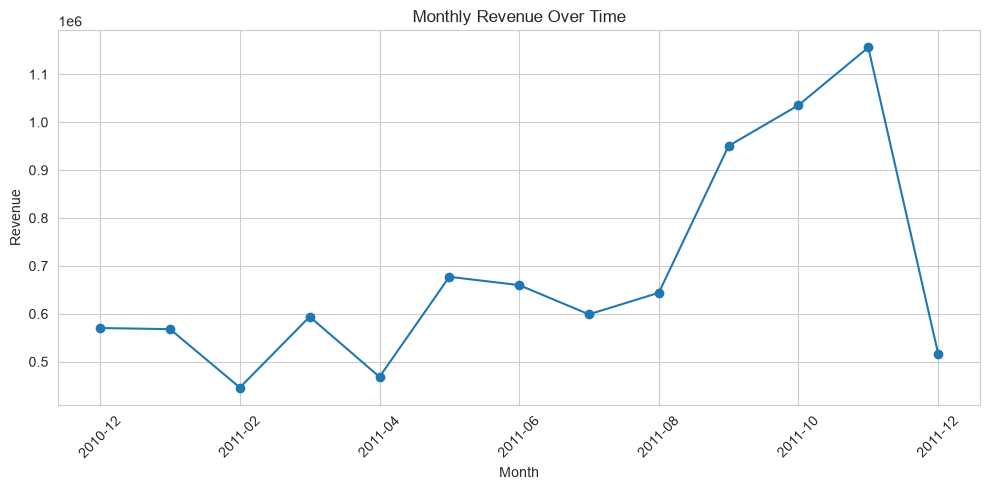

In [4]:
# Plot the monthly revenue trend as a line chart
# .astype(str) converts the Period index to plain text so matplotlib can label the x-axis correctly
fig, ax = plt.subplots()
monthly_revenue.index = monthly_revenue.index.astype(str)
monthly_revenue.plot(kind='line', marker='o', ax=ax)

ax.set_title('Monthly Revenue Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Best-selling products

We rank products two ways:
- **By quantity sold** — which items are bought most often
- **By revenue** — which items actually bring in the most money (not always the same list!)

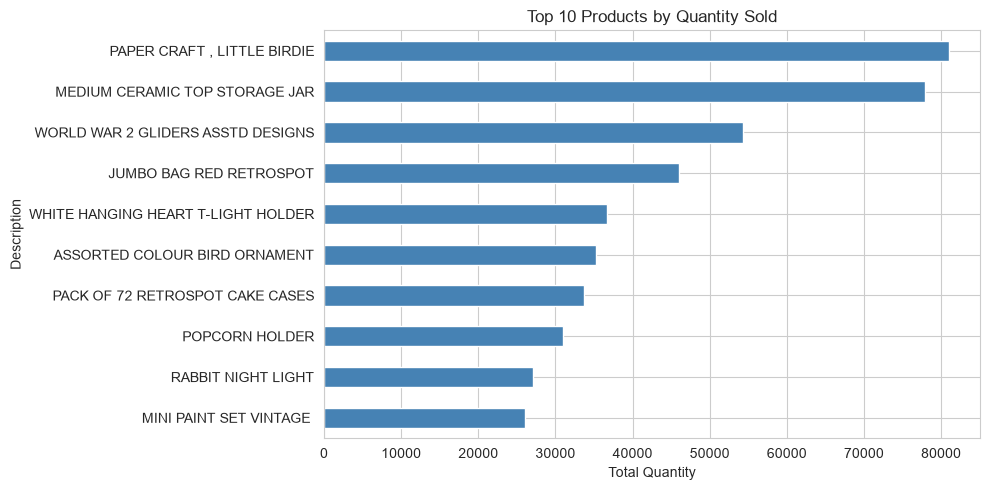

In [5]:
# Top 10 products by total quantity sold
top_by_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_by_quantity.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Products by Quantity Sold')
ax.set_xlabel('Total Quantity')
plt.tight_layout()
plt.show()

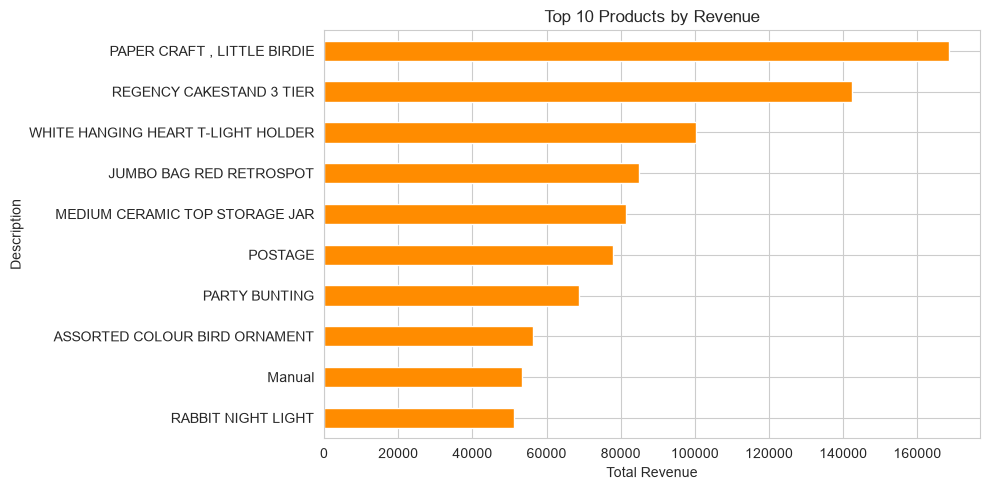

In [6]:
# Top 10 products by total revenue
top_by_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots()
top_by_revenue.sort_values().plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 10 Products by Revenue')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.show()

## 4. Sales by country

This dataset is dominated by a UK-based retailer, so we expect the United Kingdom to be the largest market by far. We check how the rest of the countries compare.

In [7]:
# Total revenue per country, sorted from highest to lowest
revenue_by_country = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

print('Top 10 countries by revenue:')
revenue_by_country.head(10)

Top 10 countries by revenue:


Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64

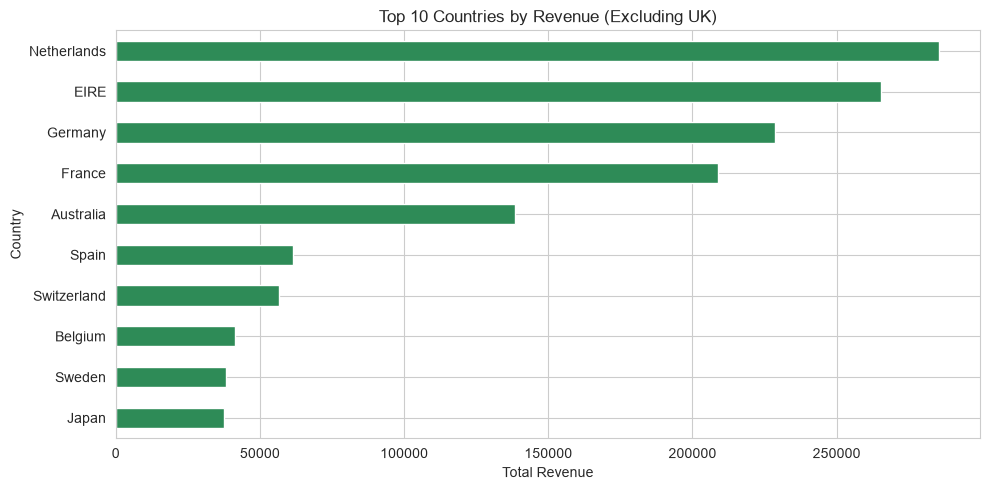

UK share of total revenue: 82.0%


In [8]:
# The UK is usually so dominant that it makes the chart unreadable for other countries.
# So we plot the top 10 countries EXCLUDING the UK to see the rest of the market clearly.
top_countries_no_uk = revenue_by_country.drop('United Kingdom').head(10)

fig, ax = plt.subplots()
top_countries_no_uk.sort_values().plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Top 10 Countries by Revenue (Excluding UK)')
ax.set_xlabel('Total Revenue')
plt.tight_layout()
plt.show()

# Show what share of total revenue the UK alone represents
uk_share = revenue_by_country['United Kingdom'] / revenue_by_country.sum() * 100
print(f'UK share of total revenue: {uk_share:.1f}%')

## 5. Customer purchase behavior

Here we look at the data from the customer's point of view instead of the product's:
- How many times does a typical customer come back and order again?
- How much does a typical order cost?

Distribution of number of orders per customer:
count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64


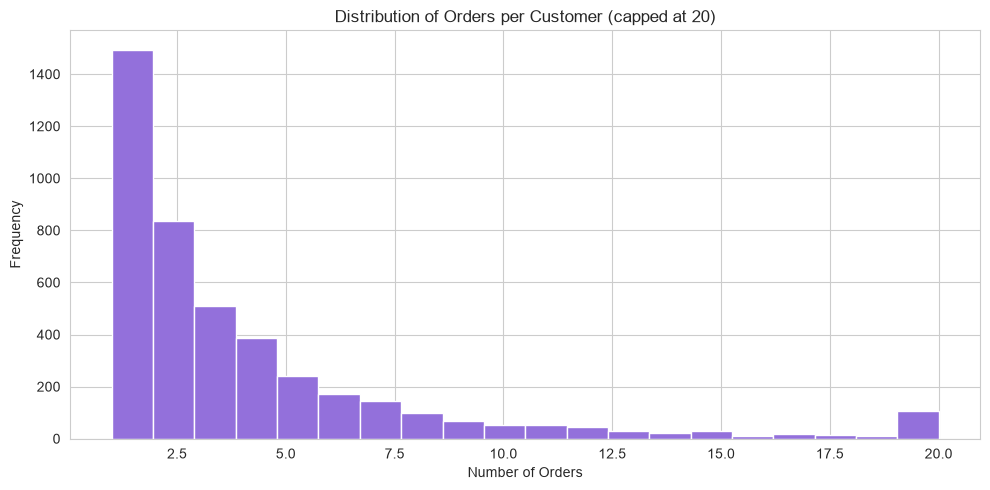

In [9]:
# Number of distinct invoices (orders) per customer = how many times they purchased
orders_per_customer = df.groupby('CustomerID')['InvoiceNo'].nunique()

print('Distribution of number of orders per customer:')
print(orders_per_customer.describe())

fig, ax = plt.subplots()
# clip(upper=20) caps extreme outliers at 20 so the histogram stays readable
orders_per_customer.clip(upper=20).plot(kind='hist', bins=20, ax=ax, color='mediumpurple')
ax.set_title('Distribution of Orders per Customer (capped at 20)')
ax.set_xlabel('Number of Orders')
plt.tight_layout()
plt.show()

Distribution of order value:
count     18532.00000
mean        479.56016
std        1678.08258
min           0.38000
25%         157.34000
50%         302.57500
75%         469.57000
max      168469.60000
Name: TotalPrice, dtype: float64


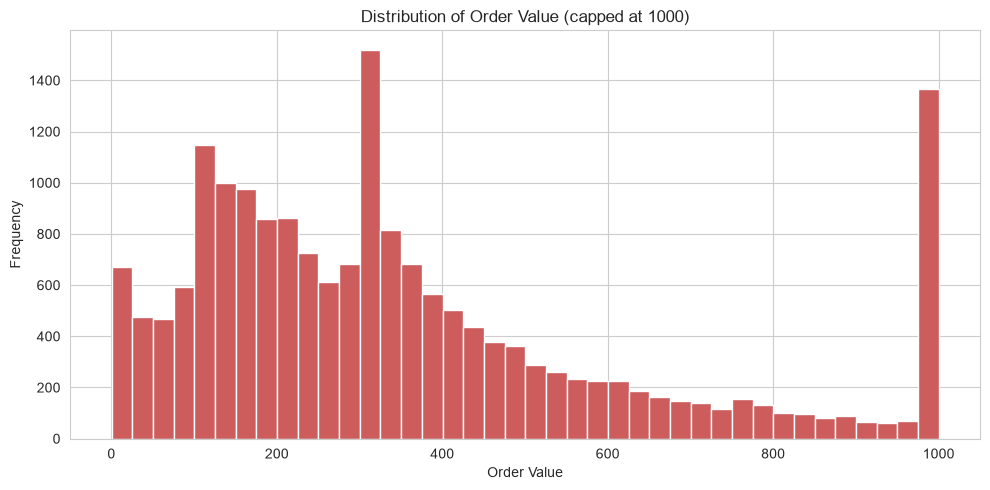

In [10]:
# Total revenue per invoice (order value), then look at the distribution
order_value = df.groupby('InvoiceNo')['TotalPrice'].sum()

print('Distribution of order value:')
print(order_value.describe())

fig, ax = plt.subplots()
# clip(upper=1000) caps extreme high-value outlier orders so the histogram stays readable
order_value.clip(upper=1000).plot(kind='hist', bins=40, ax=ax, color='indianred')
ax.set_title('Distribution of Order Value (capped at 1000)')
ax.set_xlabel('Order Value')
plt.tight_layout()
plt.show()

## 6. Summary of findings

After running the cells above, fill in your own observations here, for example:
- Which months had the highest revenue?
- Which products dominate sales?
- How dependent is the business on the UK market?
- Do most customers order once, or come back repeatedly?

These observations will guide the next steps: **customer segmentation (RFM analysis)** and **market basket analysis**.